In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# Loading the dataset
df = pd.read_csv("../data/cleaned_supply_chain_data.csv")
print(df.shape)

(180519, 52)


In [3]:
# Loading the risk model
risk_model = joblib.load("../models/risk_model.pkl")
print("Risk Model loaded successfully!")

Risk Model loaded successfully!


In [4]:
# Creating the features list
features = [
    'Sales',
    'Order Item Quantity',
    'Order Item Product Price',
    'Shipping_Duration',
    'Late_delivery_risk',
    'Estimated_Freight_Cost',
    'High_Value_Order'
]

In [5]:
# Extracting the feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': risk_model.feature_importances_
})
importance

,Feature,Importance
0,Sales,0.078769
1,Order Item Quantity,0.002395
2,Order Item Product Price,0.028105
3,Shipping_Duration,0.090647
4,Late_delivery_risk,0.653482
5,Estimated_Freight_Cost,0.066683
6,High_Value_Order,0.079918


In [6]:
# Sorting importance
importance = importance.sort_values(by='Importance', ascending=False)
importance

,Feature,Importance
4,Late_delivery_risk,0.653482
3,Shipping_Duration,0.090647
6,High_Value_Order,0.079918
0,Sales,0.078769
5,Estimated_Freight_Cost,0.066683
2,Order Item Product Price,0.028105
1,Order Item Quantity,0.002395


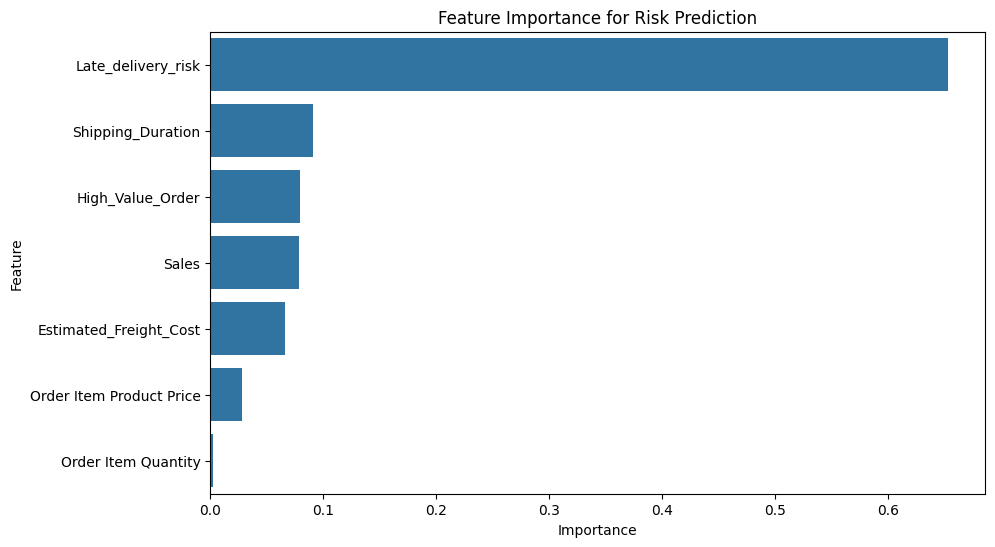

In [7]:
# Plotting Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance for Risk Prediction")
plt.show()

In [8]:
# Saving the importance report
importance.to_csv("../reports/feature_importance.csv", index=False)
print("Risk model feature importance report saved successfully!")

Risk model feature importance report saved successfully!


In [9]:
## Freight Model Explainability

In [10]:
# Loading the freight model
freight_model = joblib.load("../models/freight_model.pkl")
print("Freight Model loaded successfully!")

Freight Model loaded successfully!


In [11]:
# features
freight_features = [
    'Sales',
    'Order Item Quantity',
    'Order Item Product Price',
    'Shipping_Duration',
    'Late_delivery_risk',
    'Days for shipment (scheduled)'
]

In [12]:
# Freight importance
freight_importance = pd.DataFrame({
    'Feature': freight_features,
    'Importance': freight_model.feature_importances_
})
freight_importance

,Feature,Importance
0,Sales,8.216488e-01
1,Order Item Quantity,1.269466e-05
2,Order Item Product Price,8.843434e-02
3,Shipping_Duration,8.590408e-02
4,Late_delivery_risk,3.023798e-07
5,Days for shipment (scheduled),3.999826e-03


In [13]:
# Sort
freight_importance = freight_importance.sort_values(by='Importance', ascending=False)
freight_importance

,Feature,Importance
0,Sales,8.216488e-01
2,Order Item Product Price,8.843434e-02
3,Shipping_Duration,8.590408e-02
5,Days for shipment (scheduled),3.999826e-03
1,Order Item Quantity,1.269466e-05
4,Late_delivery_risk,3.023798e-07


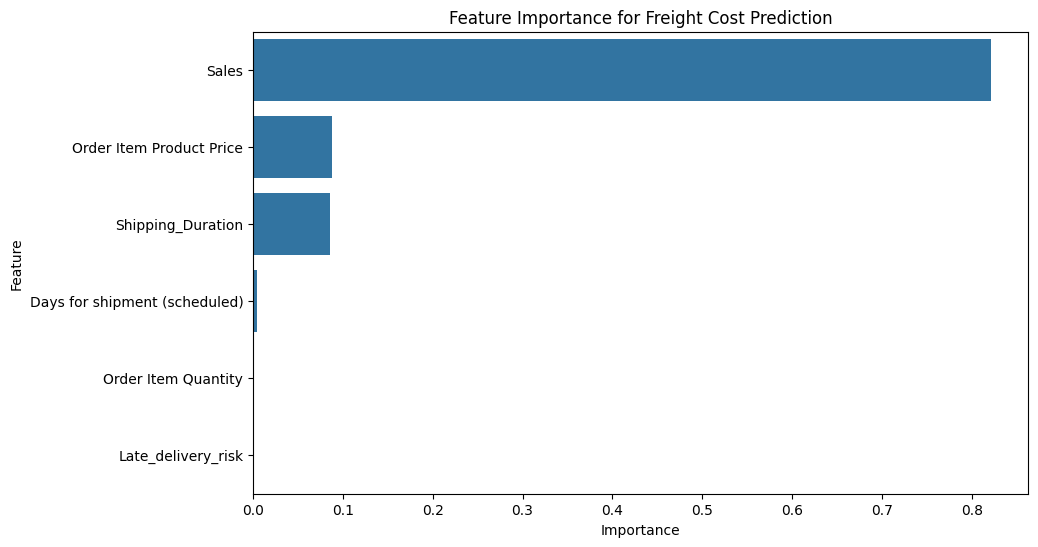

In [14]:
# Plotting feature importance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=freight_importance,
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance for Freight Cost Prediction")
plt.show()

In [15]:
# Save the importance report
freight_importance.to_csv("../reports/freight_feature_importance.csv", index=False)
print("Freight model feature importance report saved successfully!")

Freight model feature importance report saved successfully!
